# IS 4487 Assignment 5: Exploratory Data Analysis (EDA) with Stakeholder Framing

In this assignment, you will:
- Load and explore a hotel bookings dataset
- Identify stakeholder needs and frame your analysis around business goals
- Practice data summarization and visualization
- Draw insights that could lead to actionable business recommendations

## Why This Matters

These skills are essential for business majors and minors working in areas like marketing, operations, finance, or consulting. Understanding how to explore and communicate data-driven insights helps you make better decisions and contribute to real-world business outcomes.

<a href="https://colab.research.google.com/github/Stan-Pugsley/is_4487_base/blob/main/Assignments/assignment_05_eda.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>


## Dataset Description: Hotel Bookings

This dataset contains booking information for two types of hotels: a **city hotel** and a **resort hotel**. Each record corresponds to a single booking and includes various details about the reservation, customer demographics, booking source, and whether the booking was canceled.

**Source**: [GitHub - TidyTuesday: Hotel Bookings](https://github.com/rfordatascience/tidytuesday/blob/master/data/2020/2020-02-11/readme.md)

### Key Use Cases
- Understand customer booking behavior
- Explore factors related to cancellations
- Segment guests based on booking characteristics
- Compare city vs. resort hotel performance

### Data Dictionary

| Variable | Type | Description |
|----------|------|-------------|
| `hotel` | character | Hotel type: City or Resort |
| `is_canceled` | integer | 1 = Canceled, 0 = Not Canceled |
| `lead_time` | integer | Days between booking and arrival |
| `arrival_date_year` | integer | Year of arrival |
| `arrival_date_month` | character | Month of arrival |
| `stays_in_weekend_nights` | integer | Nights stayed on weekends |
| `stays_in_week_nights` | integer | Nights stayed on weekdays |
| `adults` | integer | Number of adults |
| `children` | integer | Number of children |
| `babies` | integer | Number of babies |
| `meal` | character | Type of meal booked |
| `country` | character | Country code of origin |
| `market_segment` | character | Booking source (e.g., Direct, Online TA) |
| `distribution_channel` | character | Booking channel used |
| `is_repeated_guest` | integer | 1 = Repeated guest, 0 = New guest |
| `previous_cancellations` | integer | Past booking cancellations |
| `previous_bookings_not_canceled` | integer | Past bookings not canceled |
| `reserved_room_type` | character | Initially reserved room type |
| `assigned_room_type` | character | Room type assigned at check-in |
| `booking_changes` | integer | Number of booking modifications |
| `deposit_type` | character | Deposit type (No Deposit, Non-Refund, etc.) |
| `agent` | character | Agent ID who made the booking |
| `company` | character | Company ID (if booking through company) |
| `days_in_waiting_list` | integer | Days on the waiting list |
| `customer_type` | character | Booking type: Contract, Transient, etc. |
| `adr` | float | Average Daily Rate (price per night) |
| `required_car_parking_spaces` | integer | Requested parking spots |
| `total_of_special_requests` | integer | Number of special requests made |
| `reservation_status` | character | Final status (Canceled, No-Show, Check-Out) |
| `reservation_status_date` | date | Date of the last status update |

This dataset is ideal for classification, segmentation, and trend analysis exercises.


## 1. Setup and Data Loading

Instructions:
- Import `pandas`, `seaborn`, and `matplotlib.pyplot`.
- Import data from the hotels dataset into a dataframe (in GitHub go to the DataSets folder and look for `hotels.csv`)
- Display the first few rows to confirm it loaded correctly.


In [5]:
# Your code to import libraries and load data goes here
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/Stan-Pugsley/is_4487_base/main/DataSets/hotels.csv"
df = pd.read_csv(url)

df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


## 2. Stakeholder and Business Context

### Business framing:  

Every analysis should serve a decision-maker. Before you explore the data, identify who cares about hotel booking behavior and what they might want to know. Your analysis should be framed around those needs.

### Reflection:
1. Who are the key stakeholders for this dataset?
2. What goals might each stakeholder have?
3. What is a clear, specific business problem statement that this data can help answer?





### ✍️ Your Response: 🔧
1. The key stakeholders are the resort hotel's revenue manager, reservations team, and general manager.


2. The revenue manager wants to anticipate cancellations and protect revenue. The reservations team wants to plan for bookings that might be canceled. The general manager wants to understand overall booking patterns and make better staffing and room-planning decisions.

3. For this resort hotel, how does the time between booking and arrival relate to cancellation rates, and how could the hotel use that information to plan for cancellations?




## 3. Explore Data Structure and Quality

### Business framing:  

Before diving into analysis, analysts need to understand the shape and health of the data. Bad data leads to bad decisions.

### Do the following:
- Perform the following 3 checks to see the data quality:
  - Summary the data (e.g., `.info()`, `.describe()`)
  - Find the number of Null values
  - Find the number of duplicate row checks


In [6]:
# Add code here 🔧
print("Dataset information:")
df.info()

print("\nNumeric summary:")
display(df.describe())

print("\nMissing values by column:")
print(df.isnull().sum())

print("\nNumber of fully duplicated rows:")
print(df.duplicated().sum())

print("\nNumber of negative average daily rates:")
print((df["adr"] < 0).sum())


Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9404 entries, 0 to 9403
Data columns (total 32 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   hotel                           9404 non-null   object 
 1   is_canceled                     9404 non-null   int64  
 2   lead_time                       9404 non-null   int64  
 3   arrival_date_year               9404 non-null   int64  
 4   arrival_date_month              9404 non-null   object 
 5   arrival_date_week_number        9404 non-null   int64  
 6   arrival_date_day_of_month       9404 non-null   int64  
 7   stays_in_weekend_nights         9404 non-null   int64  
 8   stays_in_week_nights            9404 non-null   int64  
 9   adults                          9404 non-null   int64  
 10  children                        9404 non-null   int64  
 11  babies                          9404 non-null   int64  
 12  meal         

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,9404.000000,9404.000000,9404.000000,9404.000000,9404.000000,9404.000000,9404.000000,9404.000000,9404.000000,9404.000000,9404.000000,9404.000000,9404.000000,9404.000000,7069.000000,1011.000000,9404.000000,9404.000000,9404.000000,9404.000000
mean,0.248299,79.326244,2015.156104,37.026584,15.515313,1.155040,3.078690,1.864738,0.095279,0.015419,0.077839,0.419715,0.290196,0.238622,200.990946,219.550940,1.019034,86.843614,0.144938,0.613143
std,0.432049,87.584146,0.443661,11.083421,9.025545,1.124304,2.379227,1.198565,0.393858,0.125781,0.267933,2.726546,1.352679,0.630041,80.330753,104.296474,10.137928,53.759940,0.353264,0.835930
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,9.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,8.000000,2015.000000,31.000000,7.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,156.000000,135.000000,0.000000,45.000000,0.000000,0.000000
50%,0.000000,48.000000,2015.000000,38.000000,16.000000,1.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,240.000000,223.000000,0.000000,71.550000,0.000000,0.000000
75%,0.000000,118.000000,2015.000000,45.000000,23.000000,2.000000,5.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,241.000000,286.000000,0.000000,120.600000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,13.000000,33.000000,55.000000,10.000000,2.000000,1.000000,26.000000,26.000000,17.000000,468.000000,511.000000,122.000000,508.000000,2.000000,5.000000



Missing values by column:
hotel                                0
is_canceled                          0
lead_time                            0
arrival_date_year                    0
arrival_date_month                   0
arrival_date_week_number             0
arrival_date_day_of_month            0
stays_in_weekend_nights              0
stays_in_week_nights                 0
adults                               0
children                             0
babies                               0
meal                                 0
country                            266
market_segment                       0
distribution_channel                 0
is_repeated_guest                    0
previous_cancellations               0
previous_bookings_not_canceled       0
reserved_room_type                   0
assigned_room_type                   0
booking_changes                      0
deposit_type                         0
agent                             2335
company                           839

### Reflection:
1. Name at least one structure issue you’ve found (e.g., missing values, formatting problems).
2. How can you fix this structural issue?

### ✍️ Your Response: 🔧
1. The biggest structural issue is missing data: `company` is missing in 8,393 bookings, `agent` in 2,335, and `country` in 266. I also found 1,674 fully duplicated rows and one negative average daily rate, which should be checked.


2. I would first check whether missing `company` and `agent` values simply mean that the booking did not involve a company or travel agent. I would investigate the negative rate as a possible error and inspect the duplicate rows before removing them, since some repeated-looking bookings could be legitimate. I would document any changes before using the data for a business decision.



## 4. Univariate Analysis

### Business framing:  

Hotels care about trends like average stay length, customer mix, and pricing. A good EDA starts with understanding single variables and their distribution.

### Do the following:
- Select at least 3 individual variables to explore
- Use plots and summary methods (e.g. info(), describe(), etc)  to describe the distribution (hint: we are only looking at the values of one variable, so think of plots you've used in the past that DON'T compare 2 variables.)
- Focus on what matters from a business standpoint (e.g., pricing, cancellations, guest types)

Cancellation counts:
is_canceled
0    7069
1    2335
Name: count, dtype: int64

Cancellation percentages:
is_canceled
0    75.2
1    24.8
Name: proportion, dtype: float64

Lead time summary:
count    9404.000000
mean       79.326244
std        87.584146
min         0.000000
25%         8.000000
50%        48.000000
75%       118.000000
max       737.000000
Name: lead_time, dtype: float64

Average daily rate summary:
count    9404.000000
mean       86.843614
std        53.759940
min        -6.380000
25%        45.000000
50%        71.550000
75%       120.600000
max       508.000000
Name: adr, dtype: float64


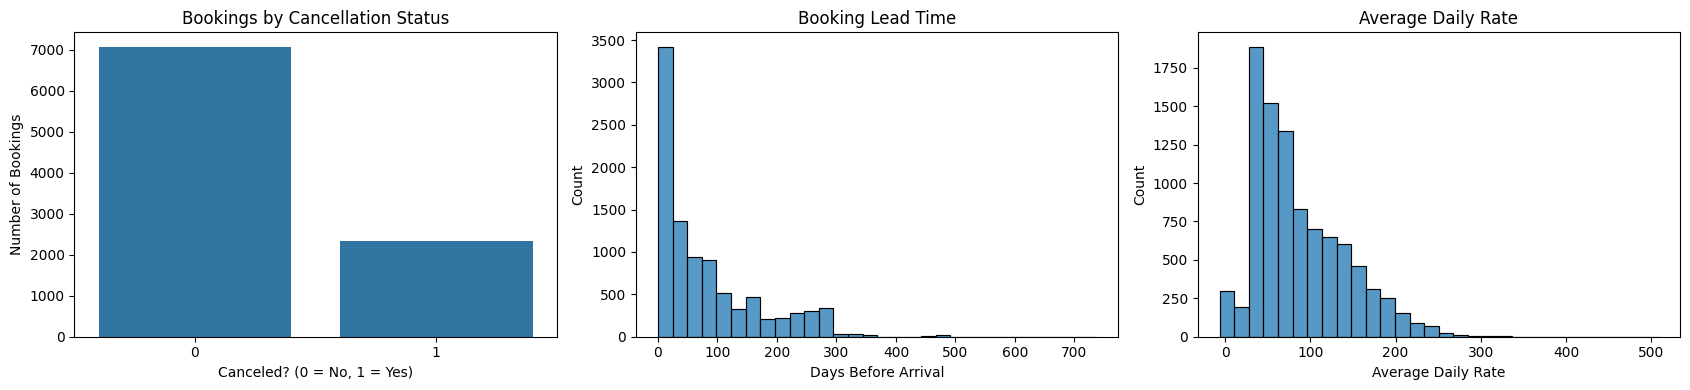

In [7]:
# Your code for univariate analysis (e.g., plots, value counts) 🔧
print("Cancellation counts:")
print(df["is_canceled"].value_counts())

print("\nCancellation percentages:")
print((df["is_canceled"].value_counts(normalize=True) * 100).round(1))

print("\nLead time summary:")
print(df["lead_time"].describe())

print("\nAverage daily rate summary:")
print(df["adr"].describe())

fig, axes = plt.subplots(1, 3, figsize=(17, 4))

sns.countplot(data=df, x="is_canceled", ax=axes[0])
axes[0].set_title("Bookings by Cancellation Status")
axes[0].set_xlabel("Canceled? (0 = No, 1 = Yes)")
axes[0].set_ylabel("Number of Bookings")

sns.histplot(data=df, x="lead_time", bins=30, ax=axes[1])
axes[1].set_title("Booking Lead Time")
axes[1].set_xlabel("Days Before Arrival")

sns.histplot(data=df, x="adr", bins=30, ax=axes[2])
axes[2].set_title("Average Daily Rate")
axes[2].set_xlabel("Average Daily Rate")

plt.tight_layout()
plt.show()

### Reflection:
1. Variable 1 – What did you explore and what did you find?
2. Variable 2 – What did you explore and what did you find?
3. Variable 3 – What did you explore and what did you find?

### ✍️ Your Response: 🔧
- **Variable 1 – Summary and insights:**  I explored `is_canceled`. Of the 9,404 bookings, 2,335 were canceled and 7,069 were not, so the cancellation rate was about 24.8%. That is a substantial share of bookings for the hotel to plan around.
- **Variable 2 – Summary and insights:**  I explored `lead_time`, the number of days between booking and arrival. The median was 48 days and the mean was about 79 days. The mean is higher because some reservations were made much farther in advance.
- **Variable 3 – Summary and insights:** I explored `adr`, or average daily rate. The median was $71.55 and the mean was about $86.84. Rates vary widely, and I would investigate the one negative value before relying on this variable for revenue analysis.


## 5. Bivariate Analysis

### Business framing:  

Stakeholders often ask: “What drives cancellations?” or “Do longer stays mean higher revenue?” Bivariate analysis helps you uncover those kinds of relationships.

### Do the following:
- Choose 2 relevant variable pairs (e.g., `lead_time` vs. `is_canceled`, or `adr` vs. `customer_type`)
- Use scatterplots, grouped bar plots, or boxplots to explore the relationships
- Interpret what these relationships could mean for the hotel business

Lead time by cancellation status:


,count,mean,median
is_canceled,,,
0,7069,63.9,34.0
1,2335,126.1,93.0


Cancellation rate by customer type:


,customer_type,count,cancellation_rate
0,Contract,581,9.5
1,Group,89,20.2
2,Transient,7031,26.5
3,Transient-Party,1703,23.5


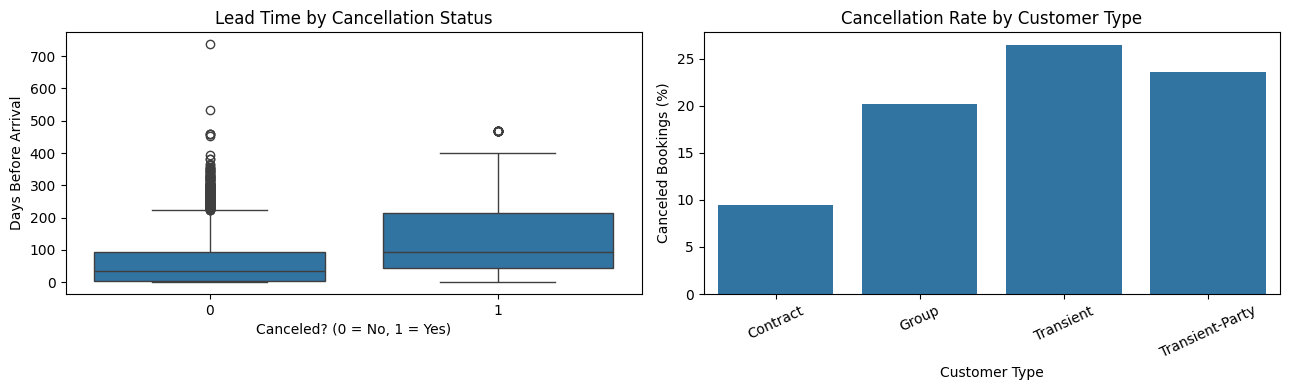

In [8]:
# Your code to analyze variable relationships (e.g., scatterplots, grouped bars) 🔧
print("Lead time by cancellation status:")
display(
    df.groupby("is_canceled")["lead_time"]
      .agg(["count", "mean", "median"])
      .round(1)
)

print("Cancellation rate by customer type:")
customer_rates = (
    df.groupby("customer_type")["is_canceled"]
      .agg(["count", "mean"])
      .reset_index()
)
customer_rates["cancellation_rate"] = customer_rates["mean"] * 100
display(customer_rates[["customer_type", "count", "cancellation_rate"]].round(1))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.boxplot(data=df, x="is_canceled", y="lead_time", ax=axes[0])
axes[0].set_title("Lead Time by Cancellation Status")
axes[0].set_xlabel("Canceled? (0 = No, 1 = Yes)")
axes[0].set_ylabel("Days Before Arrival")

sns.barplot(
    data=customer_rates,
    x="customer_type",
    y="cancellation_rate",
    ax=axes[1]
)
axes[1].set_title("Cancellation Rate by Customer Type")
axes[1].set_xlabel("Customer Type")
axes[1].set_ylabel("Canceled Bookings (%)")
axes[1].tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()

### Reflection:
1. Relationship 1 – What did you analyze and what insights did you find?
2. Relationship 2 – What did you analyze and what insights did you find?

### ✍️ Your Response: 🔧
- **Relationship 1:**  I compared `lead_time` with `is_canceled`. Canceled bookings had a median lead time of 93 days, compared with 34 days for bookings that were not canceled. Longer lead times are associated with more cancellations in this dataset, although this comparison alone does not show that booking early causes cancellation.
- **Relationship 2:**  I compared `customer_type` with `is_canceled`. Transient bookings had a cancellation rate of about 26.5%, while contract bookings had a rate of about 9.5%. This could help the hotel plan differently for different booking types, but I would examine other factors before deciding that customer type itself explains the difference.


## 6. Problem Complexity and Analytics Framing

### Business framing:  

Let’s say you found a strong trend — maybe high lead times predict cancellations, or certain channels bring repeat guests. What kind of problem is this?

- Choose one insight from your earlier analysis
- Reflect on:
  - What type of complexity this problem represents (e.g., variety, volume, variability)
  - What kind of analytics would help solve or explain it (descriptive, diagnostic, predictive, prescriptive)

### Reflection:
1. What was your selected insight?

2. What kind of complexity does it involve?
3. What type of analytics would help, and why?


### ✍️ Your Response: 🔧
1. My selected insight is that bookings made farther in advance were more likely to be canceled. Canceled bookings had a median lead time of 93 days, versus 34 days for bookings that were not canceled.
2. This involves variability because bookings have very different lead times and cancellation outcomes. Customer type and other booking details might also affect the relationship, so one variable alone may not explain it.
3. Descriptive analytics shows the difference in lead times and cancellation rates. Predictive analytics could then use information available when a reservation is made to estimate cancellation risk. The hotel could use those estimates to plan reminders and room availability, but it should test the model before relying on it.



## 7. Final Takeaways and Recommendations

### Business framing:  

Imagine you’re preparing for a stakeholder meeting. What would you highlight from your findings?

### Reflection:
- 1. What patterns or trends stood out?
- 2. How do they connect to stakeholder goals?
- 3. What recommendation would you make based on this analysis?
- 4. How does this relate to your customized learning outcome you created in canvas?



### ✍️ Your Response: 🔧

1. The clearest pattern was the relationship between lead time and cancellations. About 24.8% of bookings were canceled overall, and canceled bookings were generally made farther in advance. Cancellation rates also differed across customer types.


2. These patterns matter to the revenue manager and reservations team because cancellations affect expected occupancy, available rooms, and revenue planning.

3. I would have the hotel test a reminder or confirmation process for bookings made far in advance, then measure whether it reduces cancellations. Before acting on the customer-type differences, I would check whether other booking factors explain them.

4. My customized learning outcome involves creating and interpreting risk-related visualizations and communicating them responsibly to decision makers. Here, I used charts to show booking and cancellation risk, then explained what the patterns suggest without treating an association as proof of cause.

## Submission Instructions

✅ **Before submitting:**
- Make sure all code cells are run and outputs are visible  
- All markdown questions are answered thoughtfully  
- Submit the assignment as an **HTML file** on Canvas


In [9]:
!jupyter nbconvert --to html "assignment_05_eda.ipynb"

[NbConvertApp] WARNING | pattern 'assignment_05_eda.ipynb' matched no files
This application is used to convert notebook files (*.ipynb)
        to various other formats.


Options
The options below are convenience aliases to configurable class-options,
as listed in the "Equivalent to" description-line of the aliases.
To see all configurable class-options for some <cmd>, use:
    <cmd> --help-all

--debug
    set log level to logging.DEBUG (maximize logging output)
    Equivalent to: [--Application.log_level=10]
--show-config
    Show the application's configuration (human-readable format)
    Equivalent to: [--Application.show_config=True]
--show-config-json
    Show the application's configuration (json format)
    Equivalent to: [--Application.show_config_json=True]
--generate-config
    generate default config file
    Equivalent to: [--JupyterApp.generate_config=True]
-y
    Answer yes to any questions instead of prompting.
    Equivalent to: [--JupyterApp.answer_yes=True]
--execu